## Assignment 1.4: Spatial Power Law

For this part, we're interested in examining whether crime is evenly spread throughout the city of San Fransisco, or if it's concentrated in hotspots.

The basis of our crime analysis is **assualt** as it's our Personal Focus Crime with the highest total incident count.


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Dejavu Serif"


# Load data (only the columns we need)
data = pd.read_csv('../data/sf_crime_merged_focus_2003_2025.csv',
                    usecols=['Focus Crime', 'Latitude', 'Longitude'])

# Filter to Assault
assault = data[data['Focus Crime'] == 'Assault'].copy()
assault = assault.dropna(subset=['Latitude', 'Longitude'])

# Bounding box for SF peninsula (filter geographic outliers)
lat_min, lat_max = 37.70, 37.83
lon_min, lon_max = -122.52, -122.35

assault = assault[
    (assault['Latitude'] >= lat_min) & (assault['Latitude'] <= lat_max) &
    (assault['Longitude'] >= lon_min) & (assault['Longitude'] <= lon_max)
]

print(f"Assault incidents after filtering: {len(assault):,}")

Assault incidents after filtering: 193,078


### Steps 1–3: Grid, count, and tally

As our point of depature, we divide SF into a grid of approximately $100\mathrm{m} \times 100\mathrm{m}$ cells. At SF's latitude (~37.77°N):
- 1° latitude ≈ 111 km → 100 m ≈ 0.0009°
- 1° longitude ≈ 111 km × cos(37.77°) ≈ 87.7 km → 100 m ≈ 0.00114°

We use `np.histogram2d` to bin all Assault incidents into grid cells, then tally how many cells have exactly *k* incidents.

In [54]:
# Step 1: Create ~100m x 100m grid
deg_per_100m_lat = 0.0009
deg_per_100m_lon = 0.00114

n_lat_bins = int(np.ceil((lat_max - lat_min) / deg_per_100m_lat))
n_lon_bins = int(np.ceil((lon_max - lon_min) / deg_per_100m_lon))

print(
    f"Grid size: {n_lat_bins} lat bins x {n_lon_bins} lon bins = {n_lat_bins * n_lon_bins:,} cells"
)

# Step 2: Count incidents per cell
counts_2d, lat_edges, lon_edges = np.histogram2d(
    assault["Latitude"].values,
    assault["Longitude"].values,
    bins=[n_lat_bins, n_lon_bins],
    range=[[lat_min, lat_max], [lon_min, lon_max]],
)

# Step 3: Tally the distribution — N(k) = number of cells with exactly k incidents
cell_counts = counts_2d.flatten().astype(int)
N_k = np.bincount(cell_counts)  # N_k[k] = number of cells with exactly k incidents
k_values = np.arange(len(N_k))

print(f"Max incidents in a single cell: {cell_counts.max()}")
print(
    f"Cells with 0 incidents: {N_k[0]:,} out of {len(cell_counts):,} ({N_k[0]/len(cell_counts)*100:.1f}%)"
)
print(f"Cells with ≥1 incident: {(cell_counts > 0).sum():,}")

Grid size: 145 lat bins x 150 lon bins = 21,750 cells
Max incidents in a single cell: 3459
Cells with 0 incidents: 13,760 out of 21,750 (63.3%)
Cells with ≥1 incident: 7,990


We observe that the majority $(63.3\%)$ of the city cells have no incidents of Assault, suggesting most that incidents occur in concetrated city regions. $36.7\%$ of cells have at least 1 or more incident of Assualt.


### Step 4: Linear plot

Next, we plot the distribution of Assualt incidents per grid cell, with number of incidents $k$ $+ 1$ on the x-axis, and number of cells $N(k)$ on the y-axis. In our plotting, we use linear axes. The plotting is done below.


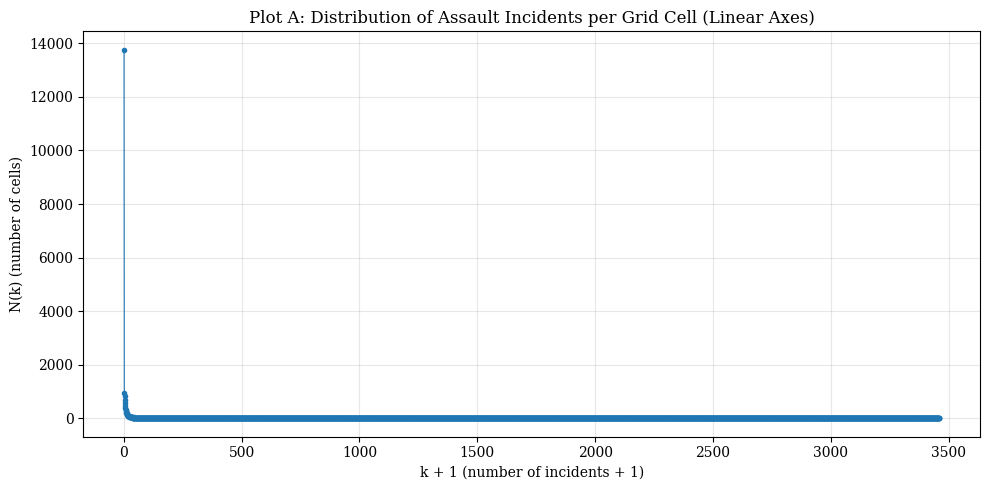

In [55]:
# Step 4: Plot (k+1) vs N(k) on linear axes
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values + 1, N_k, "o-", markersize=3, linewidth=0.8)
ax.set_xlabel("k + 1 (number of incidents + 1)")
ax.set_ylabel("N(k) (number of cells)")
ax.set_title("Plot A: Distribution of Assault Incidents per Grid Cell (Linear Axes)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 5: Log-log plot

To test for a power law, we re-plot the same distribution on logarithmic axes. If the relationship is a true power law — i.e. $N(k) \propto (k+1)^{-\alpha}$ — the data should appear as a straight line on a log-log plot. We exclude cells where $N(k) = 0$, since the logarithm is undefined there.

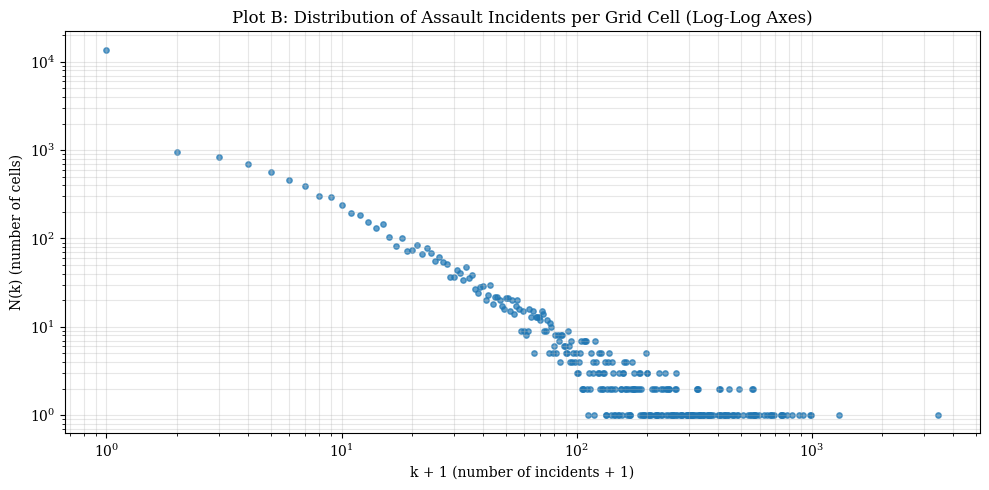

In [56]:
# Step 5: Plot (k+1) vs N(k) on log-log axes
# Filter out k values where N(k) == 0 (can't plot log of 0)
mask = N_k > 0

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(k_values[mask] + 1, N_k[mask], s=15, alpha=0.7)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("k + 1 (number of incidents + 1)")
ax.set_ylabel("N(k) (number of cells)")
ax.set_title("Plot B: Distribution of Assault Incidents per Grid Cell (Log-Log Axes)")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### Step 6: Does Assault follow a power-law spatial distribution?

The data is consistent with a power-law distribution. On the linear plot (**Plot A**), we see a dominant spike at $k = 0$ (most cells are empty) followed by a long, heavy tail extending to cells with thousands of incidents. On the log-log plot (**Plot B**), the data follows an approximately straight line from the upper-left to the lower-right across several orders of magnitude, which is the key pattern for a power law $N(k) \propto (k+1)^{-\alpha}$. There is some scatter and mild curvature at the high-$k$ tail, which expected for real-world data, but the overall pattern is well-described by a power law.

### Step 7: Implications of spatial concentration

The power-law distribution reveals a notablespatial inequality. 63% of grid cells recorded zero incidents of Assault, while a small number of hotspot cells accumulated thousands of cases. This means the "average block" crime rate of $~9$ incidents per $100\mathrm{m}$ cell is deeply misleading. The mean is dominated by a handful of extreme locations and tells us little about the typical crime rate of any given block. For neighborhood-level statistics, this implies that aggregate crime rates can conceal extreme local variation. From a policing and resource-allocation perspective, it suggests that concentrating personnel on the small fraction of ﬁhotspot cells could address a large share of total incidents.

### Partial Conclusion

Assault incidents across San Francisco are not distributed evenly in space. They are heavily concentrated in a small number of $100\mathrm{m} \times 100\mathrm{m}$ hotspot cells, with the vast majority of the city's grid cells recording no incidents. The distribution of incidents per cell follows an approximate power law, visible as a straight-line decay on log-log axes. This spatial difference means that city-wide or district-level averages conceal extreme local variation, and that more localized police interventions are likely to be more effective than city-wide approaches.